# CIS5450 Final Project
## Emma Luque, Kelli Eng, Anjana Begur

# video link
https://upenn.zoom.us/rec/share/92YzrmMK3N_-Kot-VuqjyuZR6n6mBUiC69RMMqPvtKVrnMAAdAs8z8qY7oTJhUM.Vt2y68lKGeHJzyE4?startTime=1765254178000
Passcode: 6t9?faYK

##Introduction and Background

Walkability is more recently seen as an important factor that affects community health, accessibility, and overall quality of life. Areas with higher walkability tend to support more physical activity, reduce transportation barriers, and give better access to essential resources, but walkability varies across the United States. Despite its connection to people's health, it is not as frequently analyzed alongside population-level health indicators at scale. This motivates our central problem: **How do county-level health conditions relate to walkability, and which health factors best distinguish walkable counties from non-walkable ones?**

To answer this question, our project combines two large publicly available datasets. The CDC PLACES dataset provides more than 240,000 county–measure rows, capturing the how common chronic diseases, disabilities, mental health indicators, behavioral health patterns, and preventive care metrics are for every U.S. county. The EPA Walkability Index provides a numeric score that quantifies the walkability of each census block group based on land-use diversity, street connectivity, and housing–employment balance. We aggregated these values to create a county-level walkability measure. These datasets allow us to explore walkability through the lens of community health by using a large and diverse collection of structured features.

Our exploratory data analysis (EDA) highlights how walkability varies across states, which health conditions show strong negative correlations with walkability, and how certain indicators such as coronary heart disease, obesity, and cigarette smoking seem to be closely related to whether a county is walkable.

##Approach and Methods

To answer our research question, we built a pipeline that takes the raw CDC and EPA datasets and turns them into something we can model. The CDC PLACES dataset originally had each county appearing many times, where there was one for every health measure. Since our target variable (walkability) is defined at the county level, the first step in our approach was to clean the CDC data, fix FIPS codes, remove columns with many missing values, and then pivot the data so that each county becomes a single row with one column per health indicator. Then, we merged this table with the EPA Walkability Index (NatWalkInd), which we aggregated from block-group to county level.

Once we had a single dataset, we did exploratory data analysis to understand distributions, check for missingness, and look at correlations between features. We found that many health measures were strongly correlated with each other, and based on our TA’s advice, we dropped any pairs of features with correlations above 0.8. This helps prevent linear models from being overwhelmed by redundant information. After finalizing our features, we split the data into training and testing sets and scaled the predictors using StandardScaler.

For modeling, we tried several regression methods. We started with Linear Regression because it gives us a simple baseline and interpretable coefficients. Also, we tried Ridge Regression, which is still linear but adds L2 regularization so the model handles multicollinearity better. Since walkability likely depends on more complex interactions than only straight-line relationships, we trained the tree-based models Random Forest and XGBoost. These models can capture nonlinear patterns and interactions between health indicators, and they give feature importance scores that allow us to understand which health conditions matter most.

Throughout this process, we followed the standard machine learning steps of train/test split, scaling, fitting, evaluation, and comparison of R² and MSE across models. By combining linear and nonlinear models, we were able to compare how well different approaches capture the relationship between community health and walkability, as well as which health indicators consistently show up as the strongest predictors.


# Data Cleaning/Wrangling

We are working with data from here:

https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/swc5-untb/about_data
https://catalog.data.gov/dataset/walkability-index8

In [102]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
import pandas as pd

# file paths:
cdc_path = '/content/drive/MyDrive/CIS5450_Project_Files/cdc.csv'
walkability_path = '/content/drive/MyDrive/CIS5450_Project_Files/walkability.csv'

cdc_df = pd.read_csv(cdc_path)
walkability_df = pd.read_csv(walkability_path)

/tmp/ipython-input-3175487750.py:7: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  cdc_df = pd.read_csv(cdc_path)


In [104]:
# view columns in uncleaned cdc_df
cdc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240886 entries, 0 to 240885
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        240886 non-null  int64  
 1   StateAbbr                   240886 non-null  object 
 2   StateDesc                   240886 non-null  object 
 3   LocationName                240806 non-null  object 
 4   DataSource                  240886 non-null  object 
 5   Category                    240886 non-null  object 
 6   Measure                     240886 non-null  object 
 7   Data_Value_Unit             240886 non-null  object 
 8   Data_Value_Type             240886 non-null  object 
 9   Data_Value                  240886 non-null  float64
 10  Data_Value_Footnote_Symbol  14 non-null      object 
 11  Data_Value_Footnote         14 non-null      object 
 12  Low_Confidence_Limit        240886 non-null  float64
 13  High_Confidenc

### CDC dataset: structure and attributes

- `cdc_df` contains **240,886 rows and 22 columns**. Each row corresponds to a county–year–measure observation from the CDC PLACES data.
- Most columns are **complete**: the *Non-Null Count* equals the total row count for almost all variables.  
  - The only columns with missing values are `Data_Value_Footnote` and `Data_Value_Footnote_Symbol`, which are just footnote/flag metadata. We will safely drop these later.
- Key variables for our project:
  - `StateAbbr`, `StateDesc`, `LocationName`: state and county names. These include redunant information, so only one (`StateAbbr`) will be chosen and the other two will be dropped. (categorical).
  - `LocationID`: numeric FIPS-like ID we will later join to the walkability data.
  - `Measure`: **which health measure** this row refers to (e.g., obesity, diabetes, mental distress). These are categorical labels.
  - `Data_Value` (float64): the actual **prevalence estimate**
- Almost all feature columns are either **numeric (float64/int64)** or **categorical text (`object`)**, which is compatible with our later one-hot encoding and scaling steps.
- Because we have virtually no missing numeric values, our main preprocessing decision here will be filtering down to the health measures we care about.


In [105]:
# view columns in uncleaned walkability_df
list(walkability_df.columns)

['OBJECTID',
 'GEOID10',
 'GEOID20',
 'STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'BLKGRPCE',
 'CSA',
 'CSA_Name',
 'CBSA',
 'CBSA_Name',
 'CBSA_POP',
 'CBSA_EMP',
 'CBSA_WRK',
 'Ac_Total',
 'Ac_Water',
 'Ac_Land',
 'Ac_Unpr',
 'TotPop',
 'CountHU',
 'HH',
 'P_WrkAge',
 'AutoOwn0',
 'Pct_AO0',
 'AutoOwn1',
 'Pct_AO1',
 'AutoOwn2p',
 'Pct_AO2p',
 'Workers',
 'R_LowWageWk',
 'R_MedWageWk',
 'R_HiWageWk',
 'R_PCTLOWWAGE',
 'TotEmp',
 'E5_Ret',
 'E5_Off',
 'E5_Ind',
 'E5_Svc',
 'E5_Ent',
 'E8_Ret',
 'E8_off',
 'E8_Ind',
 'E8_Svc',
 'E8_Ent',
 'E8_Ed',
 'E8_Hlth',
 'E8_Pub',
 'E_LowWageWk',
 'E_MedWageWk',
 'E_HiWageWk',
 'E_PctLowWage',
 'D1A',
 'D1B',
 'D1C',
 'D1C5_RET',
 'D1C5_OFF',
 'D1C5_IND',
 'D1C5_SVC',
 'D1C5_ENT',
 'D1C8_RET',
 'D1C8_OFF',
 'D1C8_IND',
 'D1C8_SVC',
 'D1C8_ENT',
 'D1C8_ED',
 'D1C8_HLTH',
 'D1C8_PUB',
 'D1D',
 'D1_FLAG',
 'D2A_JPHH',
 'D2B_E5MIX',
 'D2B_E5MIXA',
 'D2B_E8MIX',
 'D2B_E8MIXA',
 'D2A_EPHHM',
 'D2C_TRPMX1',
 'D2C_TRPMX2',
 'D2C_TRIPEQ',
 'D2R_JOBPOP',
 'D2R_WR

### EPA Walkability dataset: structure and attributes

- `walkability_df` contains one row per **Census block group** and **117 columns** describing demographics, auto ownership, employment, and built-environment characteristics.
- Geographic ID columns:
  - `STATEFP`, `COUNTYFP`, `TRACTCE`, `BLKGRPCE`, `GEOID10`, `GEOID20`: FIPS codes identifying each block group.
- Demographic / auto ownership variables:
  - `TotPop`, `CountHU`, `HH`, `Workers`: counts of residents, housing units, households, and workers.
  - `Pct_AO0`, `Pct_AO1`, `Pct_AO2p`: percent of households with 0, 1, or 2+ cars (we later aggregate these to county level).
  - Wage-related counts and percentages (e.g., `R_LowWageWk`, `R_PCTLOWWAGE`) capture income structure.
- Built-environment / urban form variables (our main predictors):
  - `D1*` features: different **density** metrics (residential, population, employment).
  - `D2*` features: **diversity / mix of uses**, including `D2A_EPHHM` and its ranked version.
  - `D3*` features: **street network / intersection density**, including `D3B` and `D3B_Ranked`.
  - `D4*` features: **proximity and access to transit**, including `D4A` and `D4A_Ranked`.
  - `NatWalkInd`: EPA’s composite **Walkability Index**.
- `walkability_df.dtypes` shows that:
  - ID fields are stored as integer or string codes.
  - Almost all other attributes (including `D2A_Ranked`, `D3B_Ranked`, `D4A_Ranked`, `NatWalkInd`) are **numeric (`float64` or `int64`)**, which makes them directly usable as model features after aggregation.
- In our processing we:
  - aggregate these block-group variables to the county level (`CountyFIPS`) and  
  - retain a subset of walkability-related predictors (e.g., `D2A_Ranked`, `D3B_Ranked`, `D4A_Ranked`, `Pct_AO0`, `TotPop`, `CountHu`, `HH`, `P_WrkAge`) to join with the CDC health outcomes.



In [106]:
# cleaning for cdc dataset
cols_to_keep = ['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'LocationID', 'Category', 'Short_Question_Text', 'Data_Value']

cleaned_cdc_df = cdc_df[cols_to_keep].copy()

# (for context) FIPS code = Federal Information Processing Standards code
cleaned_cdc_df = cleaned_cdc_df.rename(columns={
    'LocationName': 'CountyName',
    'LocationID': 'CountyFIPS',
    'Short_Question_Text': 'Measure',
    'Data_Value': 'Value'
})

cleaned_cdc_df['CountyFIPS'] = (cleaned_cdc_df['CountyFIPS'].astype(str).str.zfill(5))

We kept only the CDC columns relevant to health measures and renamed them for clarity (CountyName, CountyFIPS, Measure, Value). We also standardized CountyFIPS to a 5-digit code so it can merge cleanly with the walkability dataset.


In [107]:
# cleaning for walkability dataset

# creating complete fips codes for merge key
walkability_df['CountyFIPS'] = (
    walkability_df['STATEFP'].astype(str).str.zfill(2) +
    walkability_df['COUNTYFP'].astype(str).str.zfill(3)
)

# groupby to condense into per-county data, means for all metrics grouped by county fips code
county_walkability = (walkability_df
    .groupby('CountyFIPS')['NatWalkInd']
    .mean()
    .reset_index()
)

We constructed full 5-digit FIPS codes by combining state and county identifiers, ensuring both datasets use the same merge key format. We aggregated the walkability data to the county level by computing the mean National Walkability Index per CountyFIPS, since our analysis operates at the county (not block group) scale.


In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

 background info on ranks:

 To determine the walkability scores, these variables were used to rank every block group in the
United States. Each block group was assigned four ranked scores, one for each of the variables
above. To score block groups, the block groups were placed into 20 quantiles by variable value
(quantiles are groupings with equal numbers of records), each containing 5 percent of the total
block groups. The block groups were then assigned a rank from 1 to 20 depending upon their
quantile position. A ranked score of 1 was assigned to the block groups with the lowest relative
values influencing walking, and a ranked score of 20 was assigned to the block groups with the
highest relative values influencing walking, with intermediate scores in between.

- `D2A_Ranked` = a 1–20 score of the EPA’s employment–household entropy metric, which quantifies how evenly jobs and housing are distributed within a block group. Higher values represent more mixed-use, walkable urban form.
- `D3B_Ranked` = a 1-20 score that tells you how dense the street intersections are in a block group, ranked relative to all other block groups in the U.S. Higher values represent more intersections per area, a tighter grid, and shorter blocks.
- `D4A_Ranked` = a 1-20 score for proximity to transit. Block groups with no transit service get a score of 1, while those with transit access are ranked from 15–20 based on how close their population-weighted center is to the nearest transit stop (higher scores = better transit proximity).
- `Pct_AO0` = % of household w/ 0 cars
- `Pct_AO1` = % of household w/ 1 car
- `Pct_AO2p` = % of household w/ 2 cars
- `TotPop` = count of residents
- `CountHu` = total housing units in the block
- `HH` = households (occupied housing units)
- `P_WrkAge` = % of residents working-age

In [109]:
# merge cdc health-measure data with county-level walkability scores
merged = cleaned_cdc_df.merge(county_walkability, on='CountyFIPS', how='left')

# one-hot encode the 'measure' column, creates a new binary column for each unique health measure
model_df = pd.get_dummies(merged, columns=['Measure'], drop_first=False)
model_df = pd.get_dummies(model_df, columns=['StateAbbr'], drop_first=True)

# final cleanup of modeling data: standardize dummy columns to 0/1 ints and remove rows without a walkability score
grouping_cols = [col for col in model_df.columns if col.startswith('Measure_')]
model_df[grouping_cols] = model_df[grouping_cols].astype(int)
model_df = model_df.dropna(subset=['NatWalkInd'])
model_df = model_df.drop(columns=['Year', 'StateDesc', 'CountyName', 'Category'])

model_df.head()
print(f"Dataset shape: {model_df.shape}")

county_demographics = walkability_df.groupby('CountyFIPS').agg({
    'TotPop': 'sum',
    'CountHU': 'sum',
    'HH': 'sum',
    'P_WrkAge': 'mean',
    'Pct_AO0': 'mean',  # % with 0 cars
    'Pct_AO1': 'mean',  # % with 1 car
    'Pct_AO2p': 'mean', # % with 2+ cars
    'D2A_Ranked': 'mean',  # employment-housing mix
    'D3B_Ranked': 'mean', # intersection density
    'D4A_Ranked': 'mean', # pop center to nearest transit stop
    'Workers': 'sum',
}).reset_index()

# Merge demographics into your model_df
model_df = model_df.merge(county_demographics, on='CountyFIPS', how='left')



Dataset shape: (239926, 94)


We merged the cleaned CDC health-measure data with county-level walkability scores using standardized FIPS codes, then one-hot encoded the `Measure` and `StateAbbr` columns to create a wide modeling table where each health indicator and state becomes its own binary feature. Dummy columns were standardized to 0/1, rows missing walkability values were removed, and unused descriptive fields were dropped to streamline the dataset. We then aggregated the walkability dataset at the county level to compute demographic and built-environment summaries—including population, households, car-ownership rates, working-age share, and the ranked built-environment metrics (`D2A_Ranked`, `D3B_Ranked`, `D4A_Ranked`)—and merged these features into the modeling data. The resulting dataset (≈240k rows × 105 columns, as shown by `.info()` and the list of columns) contains numeric walkability scores, encoded health measures, state indicators, demographic variables, and built-environment attributes, all aligned at the county level and ready for supervised learning.

In [110]:
# Check if each row has exactly one measure
measure_cols = [col for col in model_df.columns if col.startswith('Measure_')]
measures_per_row = model_df[measure_cols].sum(axis=1)

print(f"Each row should have exactly 1 Measure flag:")
print(f"Min measures per row: {measures_per_row.min()}")
print(f"Max measures per row: {measures_per_row.max()}")
print(f"All rows have exactly 1 measure? {(measures_per_row == 1).all()}")
model_df.head()

Each row should have exactly 1 Measure flag:
Min measures per row: 1
Max measures per row: 1
All rows have exactly 1 measure? True


,CountyFIPS,Value,NatWalkInd,Measure_All Teeth Lost,Measure_Annual Checkup,Measure_Any Disability,Measure_Arthritis,Measure_Binge Drinking,Measure_COPD,Measure_Cancer (non-skin) or Melanoma,...,CountHU,HH,P_WrkAge,Pct_AO0,Pct_AO1,Pct_AO2p,D2A_Ranked,D3B_Ranked,D4A_Ranked,Workers
0,01027,11.0,3.974359,0,0,0,0,0,0,0,...,6802.0,5236.0,0.565385,0.037116,0.288933,0.673950,8.538462,2.461538,1.0,6035
1,01045,35.6,5.418605,0,0,0,1,0,0,0,...,23065.0,18670.0,0.591535,0.060620,0.333711,0.605669,10.488372,4.930233,1.0,16065
2,01071,5.1,4.803030,0,0,0,0,0,0,0,...,25106.0,20626.0,0.575727,0.041760,0.307168,0.651072,10.409091,3.704545,1.0,19944
3,01077,36.5,6.317352,0,0,0,0,0,0,0,...,44792.0,38514.0,0.585192,0.089335,0.306076,0.604589,9.767123,8.054795,1.0,33378
4,01079,40.1,3.758065,0,0,1,0,0,0,0,...,15373.0,12811.0,0.596613,0.057209,0.295679,0.647112,7.483871,2.677419,1.0,13100


We verified that each row contains exactly one health measure indicator after one-hot encoding (min = max = 1). This confirms the data is structured correctly for modeling and prevents label leakage through multiple overlapping health measure flags. Ensuring a clean, consistent row structure also informs the decision to treat measures as independent predictors rather than multi-label outcomes.

In [111]:
# for EDA visuals flip cdc table so we get health indicator cols per county
cdc_pivot = cleaned_cdc_df.pivot_table(
    index='CountyFIPS',
    columns='Measure',
    values='Value',
    aggfunc='mean'
).reset_index()

# combine dfs on county fips code
eda_vis_df = county_walkability.merge(cdc_pivot, on='CountyFIPS', how='inner')
eda_vis_df = eda_vis_df.dropna(subset=['NatWalkInd'])

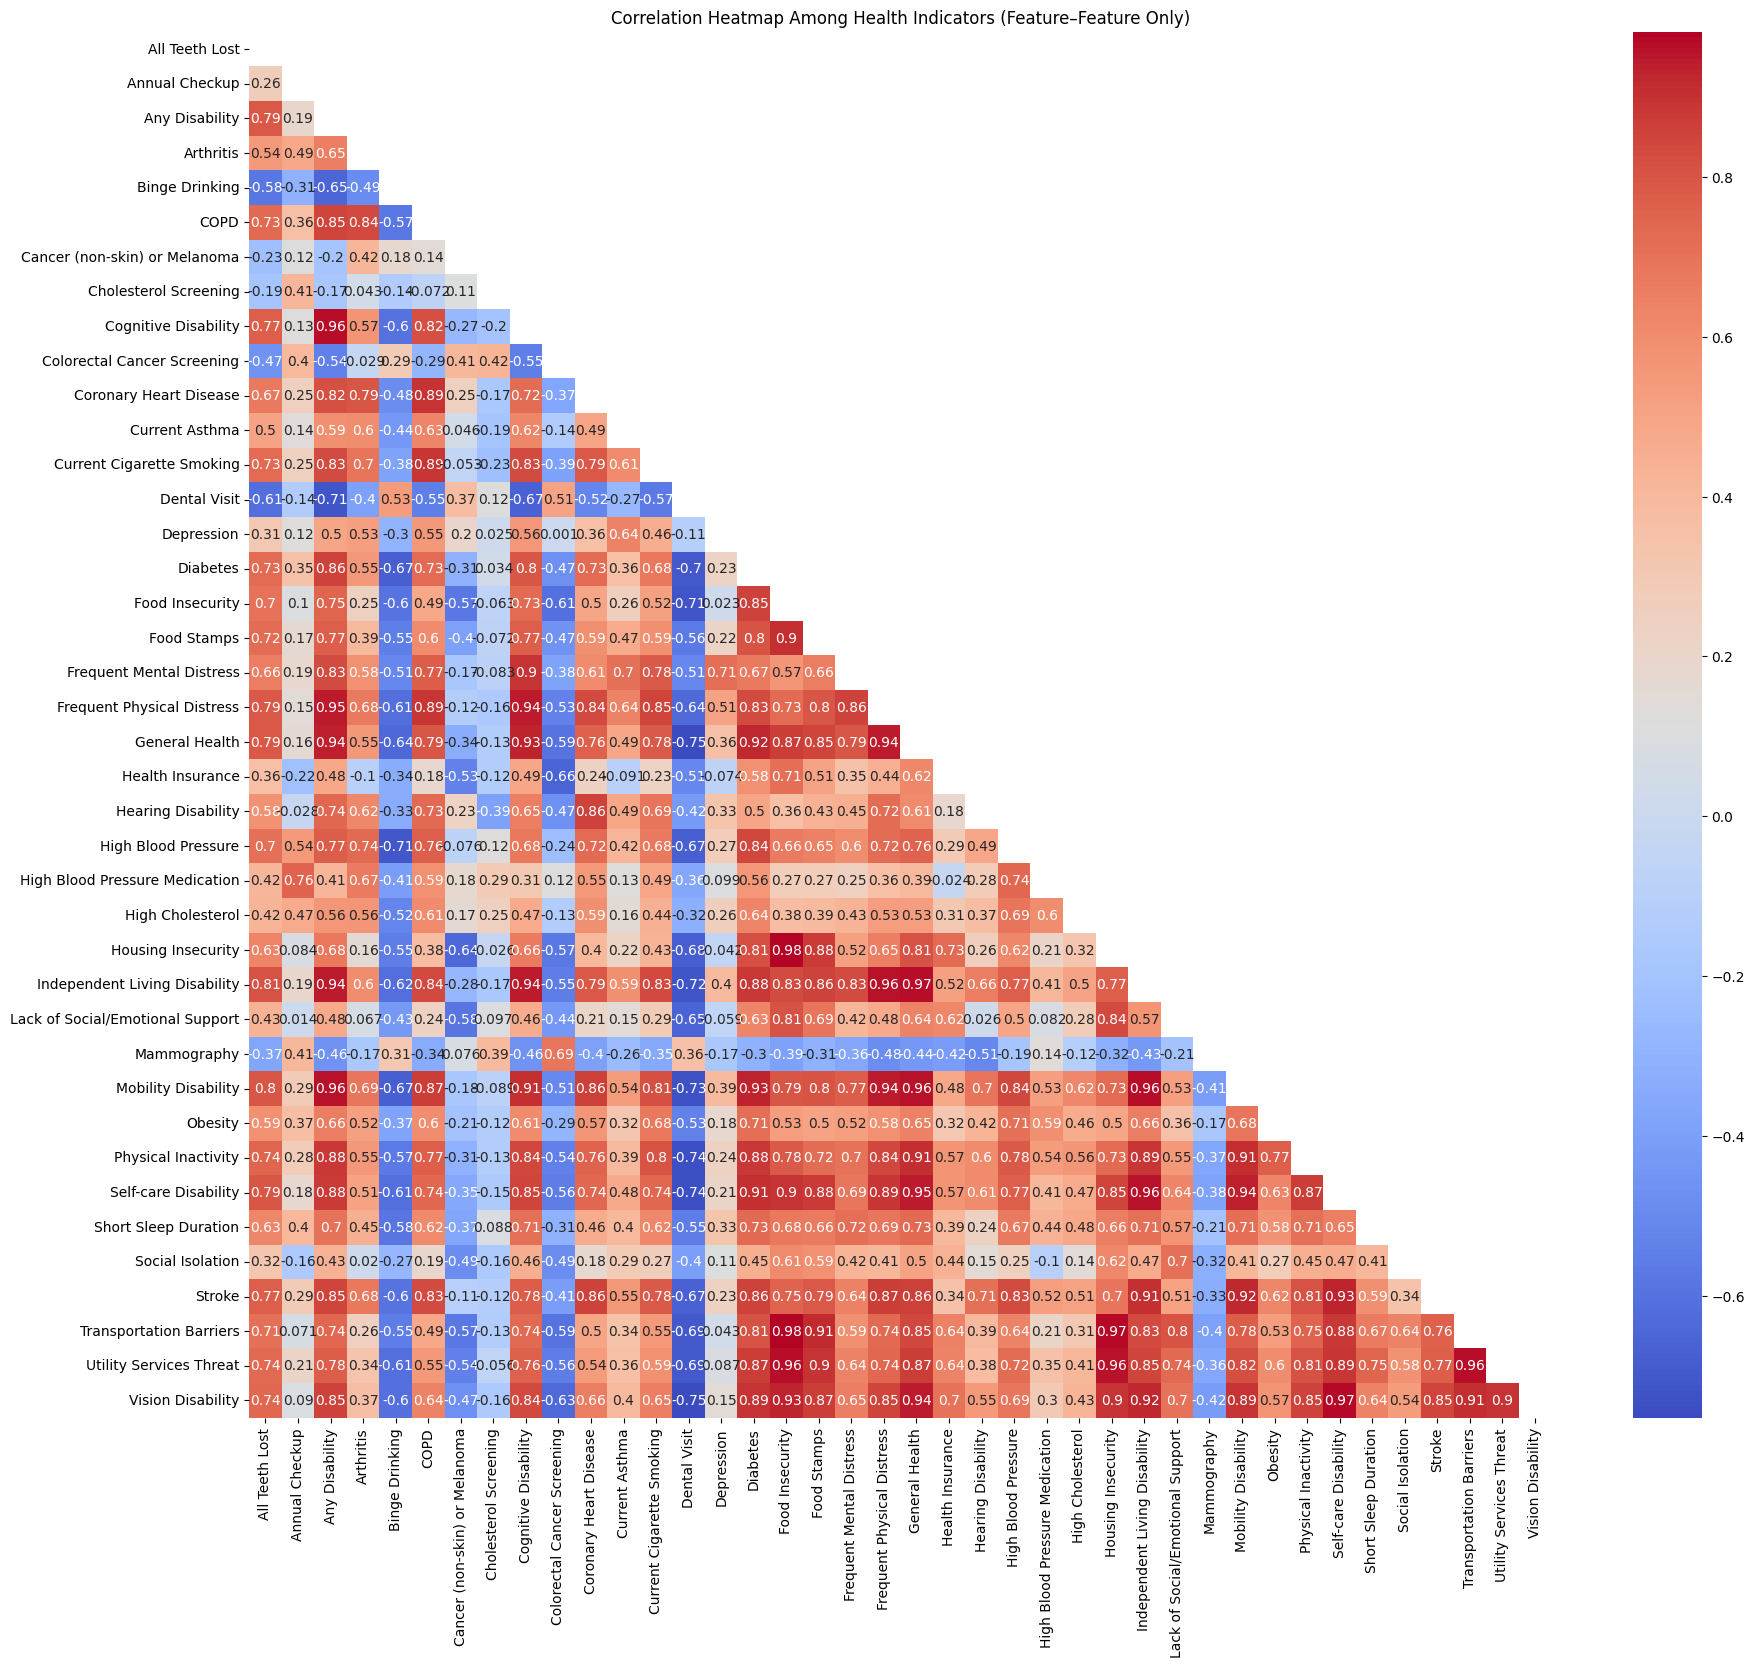

In [112]:
# data cleaning: correlation heatmap for feature-feature correlation (for removal of highly correlated variables w/ > 0.8 correlation)
feature_cols = eda_vis_df.drop(columns=['CountyFIPS', 'NatWalkInd']).columns
feature_df = eda_vis_df[feature_cols]

corr_matrix = feature_df.corr()

plt.figure(figsize=(21, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap Among Health Indicators (Feature–Feature Only)")
plt.show()

The correlation heatmap shows strong clusters of highly correlated health measures—for example, chronic conditions and disability indicators group tightly together. This reveals redundancy in the original CDC dataset and motivates later feature reduction steps (dropping highly correlated columns before modeling). These patterns also reinforce the need for regularized models (like Ridge) and tree-based models (Random Forest/XGBoost), which can handle multicollinearity and nonlinear interactions more effectively.

In [113]:
# data cleaning: health indicators with lots of null values
eda_vis_df.isna().sum()

,0
CountyFIPS,0
NatWalkInd,0
All Teeth Lost,0
Annual Checkup,0
Any Disability,0
Arthritis,0
Binge Drinking,0
COPD,0
Cancer (non-skin) or Melanoma,0
Cholesterol Screening,67


This check shows that only a small subset of health indicators has a noticeable number of null values (e.g., Food Insecurity, Housing Insecurity). Flagging these columns early allows us to remove them before modeling, preventing incomplete features from distorting correlations, training signals, or model performance.

In [114]:
# final cleaning for model_df & eda_vis_df

# drop columns with lots of null values
null_cols = [
    'Food Insecurity',
    'Food Stamps',
    'Housing Insecurity',
    'Lack of Social/Emotional Support',
    'Social Isolation',
    'Transportation Barriers',
    'Utility Services Threat'
]

# drop highly correlated columns
high_corr_cols = [
    'Any Disability',
    'Cognitive Disability',
    'Hearing Disability',
    'Vision Disability',
    'Mobility Disability',
    'Self-care Disability',
    'High Blood Pressure',
    'High Cholesterol',
    'Stroke',
    'Frequent Mental Distress',
    'Frequent Physical Distress',
    'COPD',
    'High Blood Pressure Medication',
    'General Health',
    'Independent Living Disability',
    'Physical Inactivity'
]

# these columns measure healthcase visits/screenings, not actual health conditions, so they don't fit
# what we actually want to model, so drop them
irrel_cols = [
    'Annual Checkup',
    'Cholesterol Screening',
    'Colorectal Cancer Screening',
    'Dental Visit'
]

def add_prefix(cols):
    return [f"Measure_{c}" for c in cols]

model_cols_to_drop = add_prefix(null_cols) + add_prefix(high_corr_cols) + add_prefix(irrel_cols)
model_df = model_df.drop(columns=model_cols_to_drop)
eda_cols_to_drop = null_cols + high_corr_cols + irrel_cols
eda_vis_df = eda_vis_df.drop(columns=eda_cols_to_drop)


In [115]:
# after cleaning, dataset has 50,000+ rows
print("size: ")
print(str(model_df.size))
print("shape: ")
model_df.shape

size: 
18714228
shape: 


(239926, 78)

After dropping columns with many null values, removing highly correlated health indicators, and excluding irrelevant visit/screening measures, the final `model_df` is a clean, modeling-ready dataset with 239,926 rows and 78 features. The remaining columns represent non-redundant health-condition indicators, county demographics, and walkability scores, giving us a focused feature set that avoids noise and multicollinearity while keeping only variables that meaningfully relate to our prediction task.

# EDA Visualizations

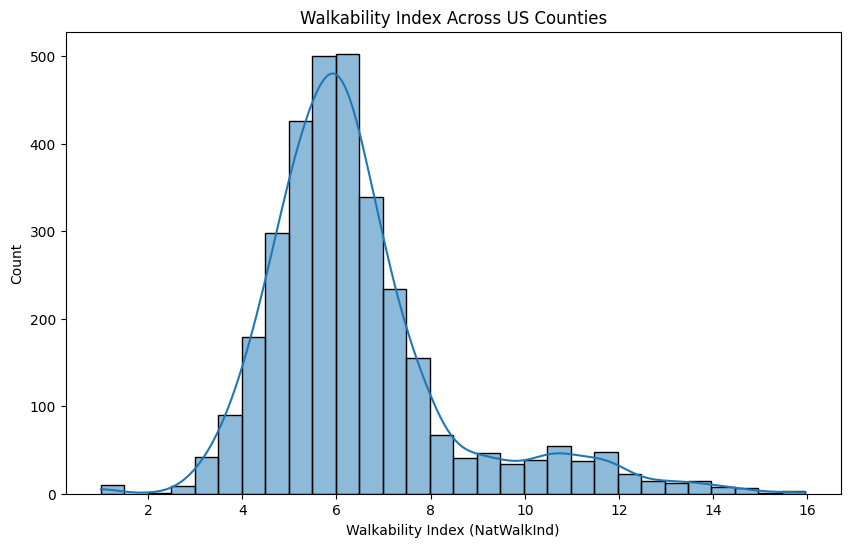

In [116]:
# EDA visual 1
# distribution of walkability index across counties

plt.figure(figsize=(10,6))
sns.histplot(county_walkability['NatWalkInd'], kde=True, bins=30)
plt.title("Walkability Index Across US Counties")
plt.xlabel("Walkability Index (NatWalkInd)")
plt.ylabel("Count")
plt.show()

### EDA 1 Summary: Distribution of Walkability

This histogram shows the distribution of walkability index values across U.S. counties.
The distribution is slightly right-skewed, with most counties having a walkability index
between 4 and 8. A small number of counties exceed 12–14, suggesting a long tail of highly
walkable counties (likely dense urban areas). Understanding this distribution helps frame
the prediction problem and highlights potential outliers.

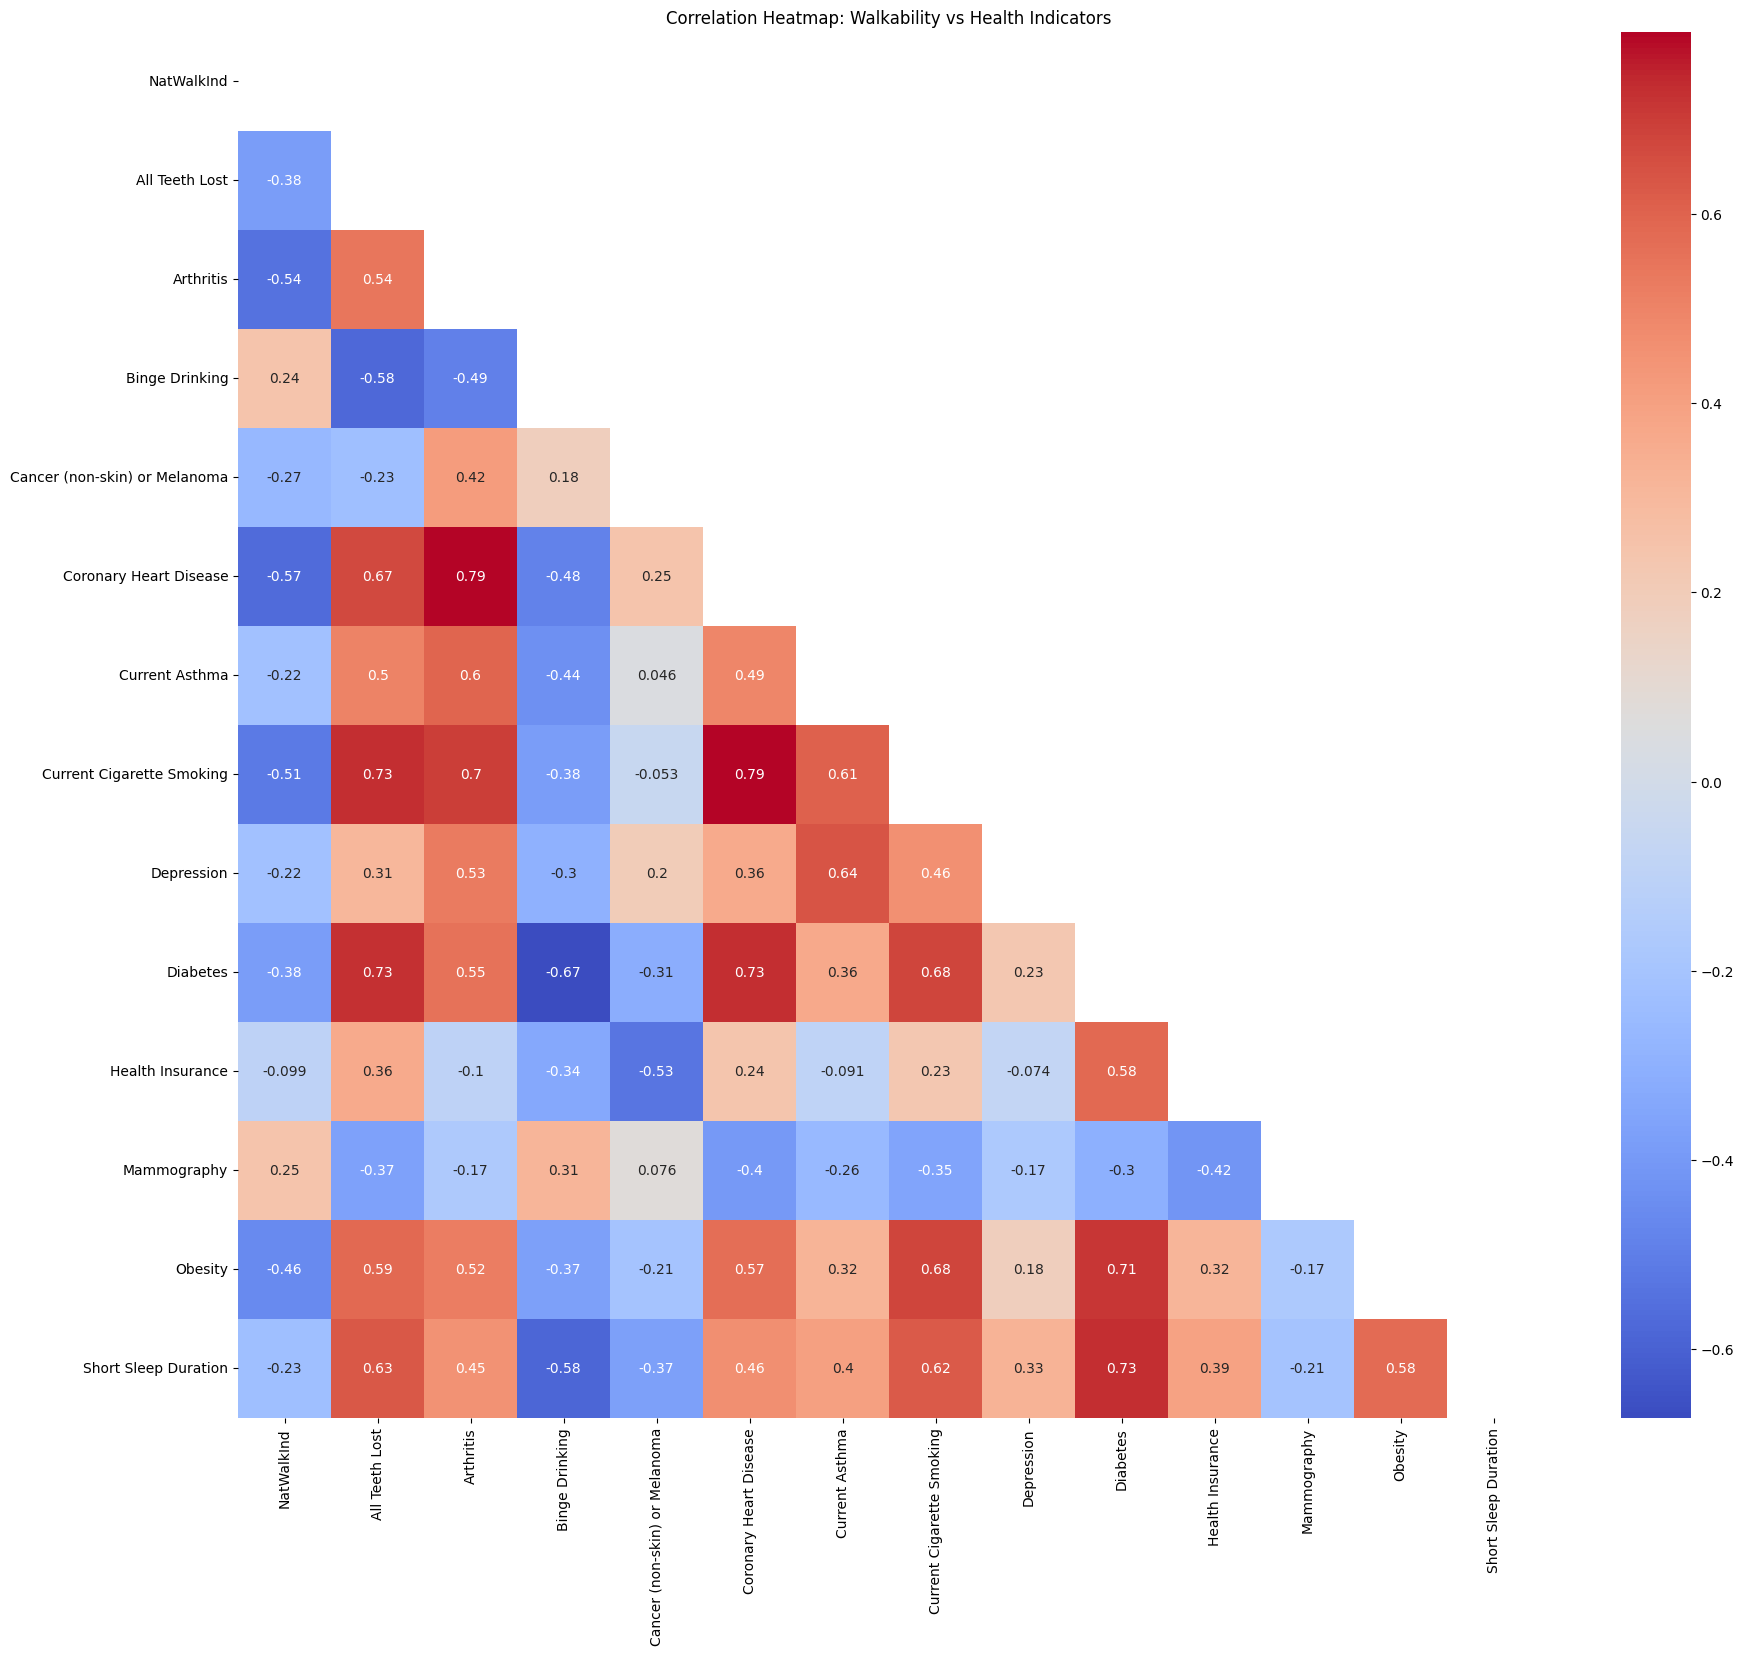

In [117]:
# EDA visual 2
# correlation heatmap between health indicators and walkability
corr = eda_vis_df.corr(numeric_only=True)

plt.figure(figsize=(21, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Walkability vs Health Indicators")
plt.show()

### EDA 2 Summary: Correlation Between Health Indicators and Walkability

The correlation heatmap reveals which health indicators have the strongest linear
relationships with walkability. Notably, coronary heart disease, arthritis, cigarette
smoking, and obesity all have moderately strong negative correlations with walkability
(-0.46 to -0.57). This suggests that counties with poorer health outcomes tend to have
lower walkability. This insight helps motivate which features to explore more deeply in
modeling and visualization.

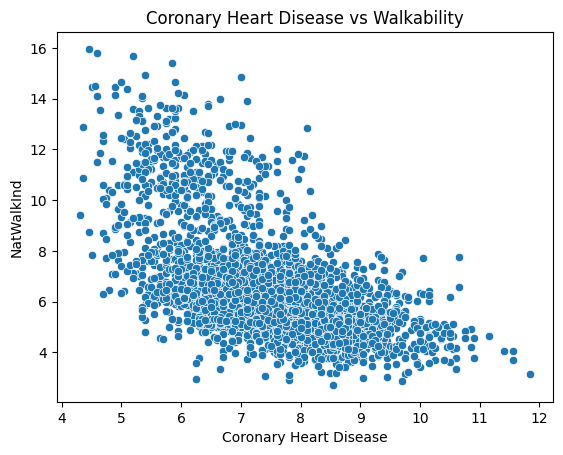

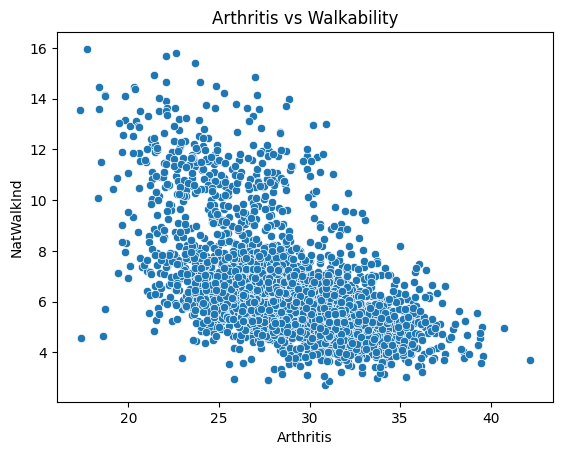

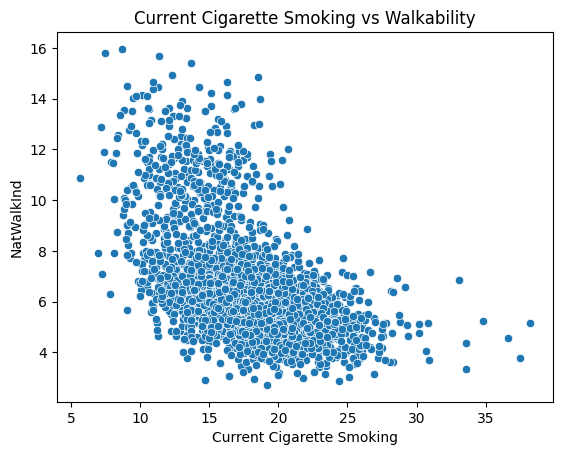

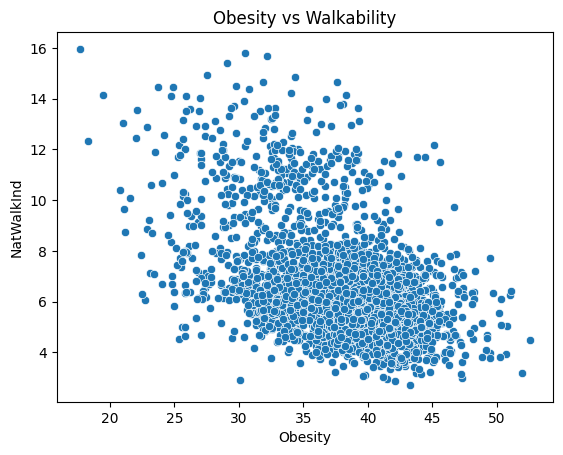

In [118]:
# EDA visual 3
# scatterplots showing relationship b/w key predictors and walkability

# Coronary Heart Disease & NatWalkInd had a -0.57 correlation
sns.scatterplot(data=eda_vis_df, x='Coronary Heart Disease', y='NatWalkInd')
plt.title("Coronary Heart Disease vs Walkability")
plt.show()

# Arthritis & NatWalkInd had a -0.54 correlation
sns.scatterplot(data=eda_vis_df, x='Arthritis', y='NatWalkInd')
plt.title("Arthritis vs Walkability")
plt.show()

# Current Cigarrete Smoking & NatWalkInd had a -.51 correlation
sns.scatterplot(data=eda_vis_df, x='Current Cigarette Smoking', y='NatWalkInd')
plt.title("Current Cigarette Smoking vs Walkability")
plt.show()

# Obesity & NatWalkInd had a -0.46 correlation
sns.scatterplot(data=eda_vis_df, x='Obesity', y='NatWalkInd')
plt.title("Obesity vs Walkability")
plt.show()

### EDA 3 Summary: Key Feature Relationships

Scatterplots confirm the negative linear relationship between walkability and several major
health indicators. For example, as rates of coronary heart disease or arthritis increase,
walkability tends to decrease. Similar downward trends are observed for cigarette smoking
and obesity. These visual patterns support the correlation findings and indicate features
that may be strong predictors in our regression models.

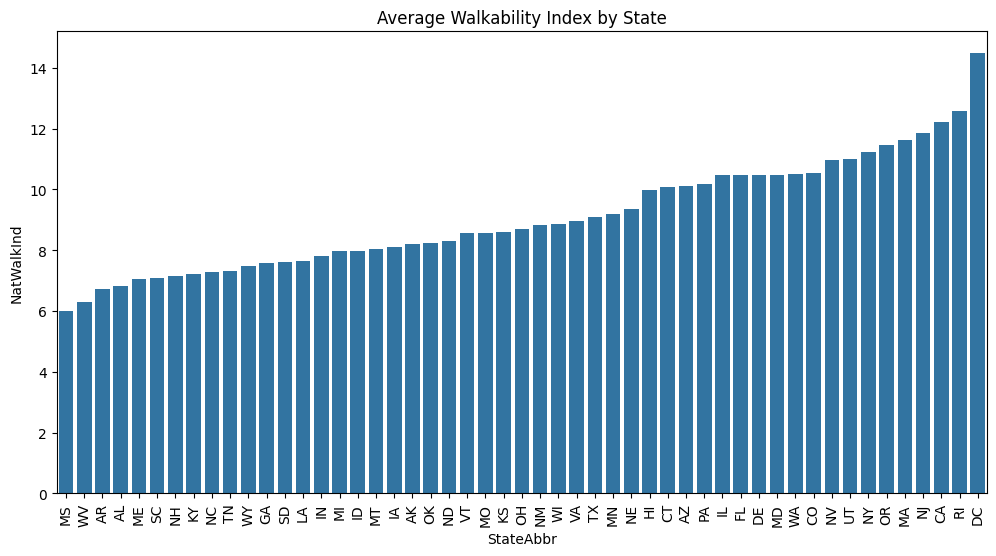

In [119]:
# EDA visual 4
# walkability by region, state, county (?) using aggregation

state_fp_to_abbr = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO",
    "09": "CT", "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI",
    "16": "ID", "17": "IL", "18": "IN", "19": "IA", "20": "KS", "21": "KY",
    "22": "LA", "23": "ME", "24": "MD", "25": "MA", "26": "MI", "27": "MN",
    "28": "MS", "29": "MO", "30": "MT", "31": "NE", "32": "NV", "33": "NH",
    "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH",
    "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD",
    "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA",
    "54": "WV", "55": "WI", "56": "WY"
}

walkability_df['STATEFP'] = walkability_df['STATEFP'].astype(str).str.zfill(2)

walkability_df['StateAbbr'] = walkability_df['STATEFP'].map(state_fp_to_abbr)

state_walkability = (
    walkability_df
    .groupby('StateAbbr')['NatWalkInd']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=state_walkability, x='StateAbbr', y='NatWalkInd')
plt.xticks(rotation=90)
plt.title("Average Walkability Index by State")
plt.show()

### EDA 4 Summary: Geographic Trends in Walkability

Aggregating walkability scores at the state level shows clear geographic variation. States
like CA, NY, MA, and DC exhibit the highest average walkability, while many southern and
midwestern states have lower walkability. This visualization highlights broader structural
and regional patterns that may influence walkability independently of health indicators.


         NatWalkInd  Obesity  Diabetes  Coronary Heart Disease
Cluster                                                       
0              6.28    37.53     11.82                    7.50
1              6.85    39.55     14.08                    7.25
2              5.27    41.88     15.03                    8.73
3              7.73    33.86      9.93                    6.31

Cluster sizes: {0: 1156, 1: 364, 2: 748, 3: 865}


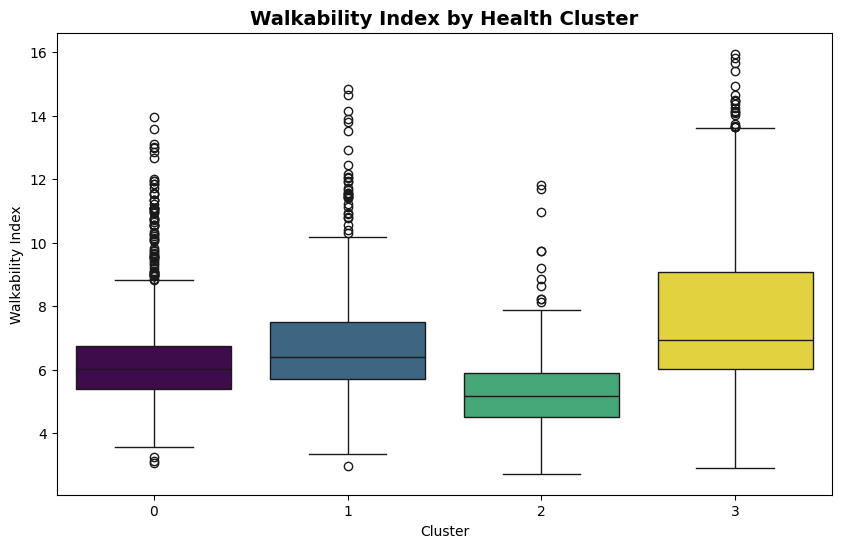

In [120]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use county-level data for clustering
cluster_df = eda_vis_df.drop(columns=['CountyFIPS', 'NatWalkInd']).dropna()
cluster_walkability = eda_vis_df.loc[cluster_df.index, 'NatWalkInd']

# Scale features
scaler_kmeans = StandardScaler()
cluster_scaled = scaler_kmeans.fit_transform(cluster_df)

# Fit K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

# Add clusters to data
cluster_results = eda_vis_df.loc[cluster_df.index].copy()
cluster_results['Cluster'] = clusters

# Show cluster statistics
cluster_summary = cluster_results.groupby('Cluster').agg({
    'NatWalkInd': 'mean',
    'Obesity': 'mean',
    'Diabetes': 'mean',
    'Coronary Heart Disease': 'mean'
}).round(2)


print(cluster_summary)
print(f"\nCluster sizes: {cluster_results['Cluster'].value_counts().sort_index().to_dict()}")

# Visualize walkability by cluster
plt.figure(figsize=(10, 6))
sns.boxplot(data=cluster_results, x='Cluster', y='NatWalkInd', palette='viridis', legend=False, hue='Cluster')
plt.title('Walkability Index by Health Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Walkability Index')
plt.show()

# Adding as a column in model df to be used as a feature in later models
cluster_labels = cluster_results[['CountyFIPS', 'Cluster']].copy()

# Merge into model_df
model_df = model_df.merge(cluster_labels, on='CountyFIPS', how='left')

# One-hot encode clusters
model_df = pd.get_dummies(model_df, columns=['Cluster'], prefix='HealthCluster')



### EDA 5: K-Means Clustering of County Health Profiles

We use K-Means clustering to group counties by their health characteristics and examine
whether these groups differ in walkability. K-Means clustering grouped counties into 4 distinct health profiles based on their health
indicators. The clusters show clear differences in walkability: healthier clusters (lower
obesity, diabetes, heart disease) tend to have higher walkability scores (~7.73), while less healthy
clusters have lower walkability (5.27-6.85). This unsupervised analysis confirms that counties naturally
segment by health status and that these segments correspond to different walkability levels.


# Models
##### baseline: Ridge regression
##### model 2: Random Rorest
##### model 3: XGBoost

### Model Selection and Justification

#### Model 1: Ridge Regression (Baseline)

**Why Ridge:**
- Linear assumptions allow us to quantify relationships more simply ie 1-unit increase in feature X corresponds to y change in walkability"
- Fast to train, suitable for understanding direct linear relationships

**Limitations:**
- Assumes linear relationships
- Cannot capture feature interactions (e.g., obesity + diabetes combined effect)
- May underfit if true relationships are complex

**For Our Problem:**
Given the moderate correlations we inferred in our EDA, Ridge is a good starting point to understand whether simple linear relationships explain
walkability variance.

#### Model 2: Random Forest (Complex Model #1)

**Why Random Forest:**
- Captures nonlinear relationships without manual feature engineering
- Handles feature interactions automatically (e.g., high obesity + rural state → compounded effect)
- Provides feature importance rankings to understand which predictors matter most
- Robust to outliers and doesn't require feature scaling (though we scale for consistency)
- Our Ridge underfitted (R^2 = 0.29), so Random Forest would be able to capture complex patterns that the Ridge misses

**Limitations:**
- Less interpretable than Ridge due to the ensemble of many trees
- Can overfit if not properly tuned ( we addressed this through hyperparameter tuning)
- Takes a long time/is computationally expensive: we had to adjust our tuning set to a sample of the actual data because of this issue

**For Our Problem:**
EDA showed walkability varies dramatically by state and that health indicators may interact
with geography. Random Forest can discover these patterns without manual specification.

#### Model 3: XGBoost (Complex Model #2)

**Why XGBoost:**
- Gradient boosting often outperforms Random Forest
- Sequential tree building focuses on correcting previous errors which leads to better optimization than RF because the trees get better each iteration
- More sophisticated than Random Forest at finding subtle patterns


**Limitations:**
- Most complex model, can lead to a black box effect
- Slower to train than Random Forest (sequential trees)

**For Our Problem:**
XGBoost represents our best attempt at maximum predictive accuracy. By comparing all three
models, we can assess whether the added complexity yields meaningful performance gains over
simpler approaches.

#### Pipeline Design to Prevent Data Leakage

1. **GroupShuffleSplit:** We split by county (not by rows) because each county appears
   multiple times (once per health measure). After getting initial R^2 values of 0.99, we realized that random splitting would leak information where
   model would see County A's obesity in training and County A's diabetes in testing,
   allowing it to memorize County A's walkability rather than learning generalizable patterns.

2. **Removed Walkability Components:** We dropped D2A_Ranked, D3B_Ranked, and D4A_Ranked
   because these are components used to calculate NatWalkInd. Including them would cause target leakage.



In [121]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [122]:
# group shuffle step - to prevent data leakage from walkability components
from sklearn.model_selection import GroupShuffleSplit

# Get county IDs for each row
county_groups = model_df['CountyFIPS'].values

# Prepare features and target
X = model_df.drop(columns=['CountyFIPS', 'NatWalkInd','D2A_Ranked', 'D3B_Ranked', 'D4A_Ranked','TotPop',
    'CountHU',
    'HH',
    'Workers',
    'P_WrkAge',
    'Pct_AO0',
    'Pct_AO1',
    'Pct_AO2p',
    'Value',], errors='ignore')
y = model_df['NatWalkInd']

# Split by county (not by rows), this ensures all rows from a county go to either train or test but dont get split over both
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=county_groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# continue with imputation and scaling
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


In [123]:
# Model 1: Ridge Regression with tuning
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

print("Ridge Best Alpha:", ridge.best_params_)
print("Ridge R²:", r2_score(y_test, ridge_preds))
print("Ridge MSE:", mean_squared_error(y_test, ridge_preds))

Ridge Best Alpha: {'alpha': 100.0}
Ridge R²: 0.4246974886476367
Ridge MSE: 2.2400002011153606


In [124]:
# Model 2: Random Forest
# hyperparameter training
X_train_sample = X_train_scaled[:40000]  # Use first 40k rows to quickly tune
y_train_sample = y_train[:40000]

rf_params = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
rf.fit(X_train_sample, y_train_sample)

# Retrain on full data
best_rf = rf.best_estimator_
best_rf.fit(X_train_scaled, y_train)
rf_preds = best_rf.predict(X_test_scaled)

print("RF Best Alpha:", rf.best_params_)
print("RF R²:", r2_score(y_test, rf_preds))
print("RF MSE:", mean_squared_error(y_test, rf_preds))

RF Best Alpha: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RF R²: 0.4107263585065869
RF MSE: 2.2943982503298415


In [125]:
# Model 3: XGBoost with tuning
import xgboost as xgb

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],  # fraction of samples per tree
    'colsample_bytree': [0.8, 1.0]  # fraction of features per tree
}

xgb_model = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

print("XGBoost Best Params:", xgb_model.best_params_)
print("XGBoost R²:", r2_score(y_test, xgb_preds))
print("XGBoost MSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
XGBoost Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
XGBoost R²: 0.4237188129584317
XGBoost MSE: 2.243810776764496
XGBoost MAE: 1.0652127694949909


# Results

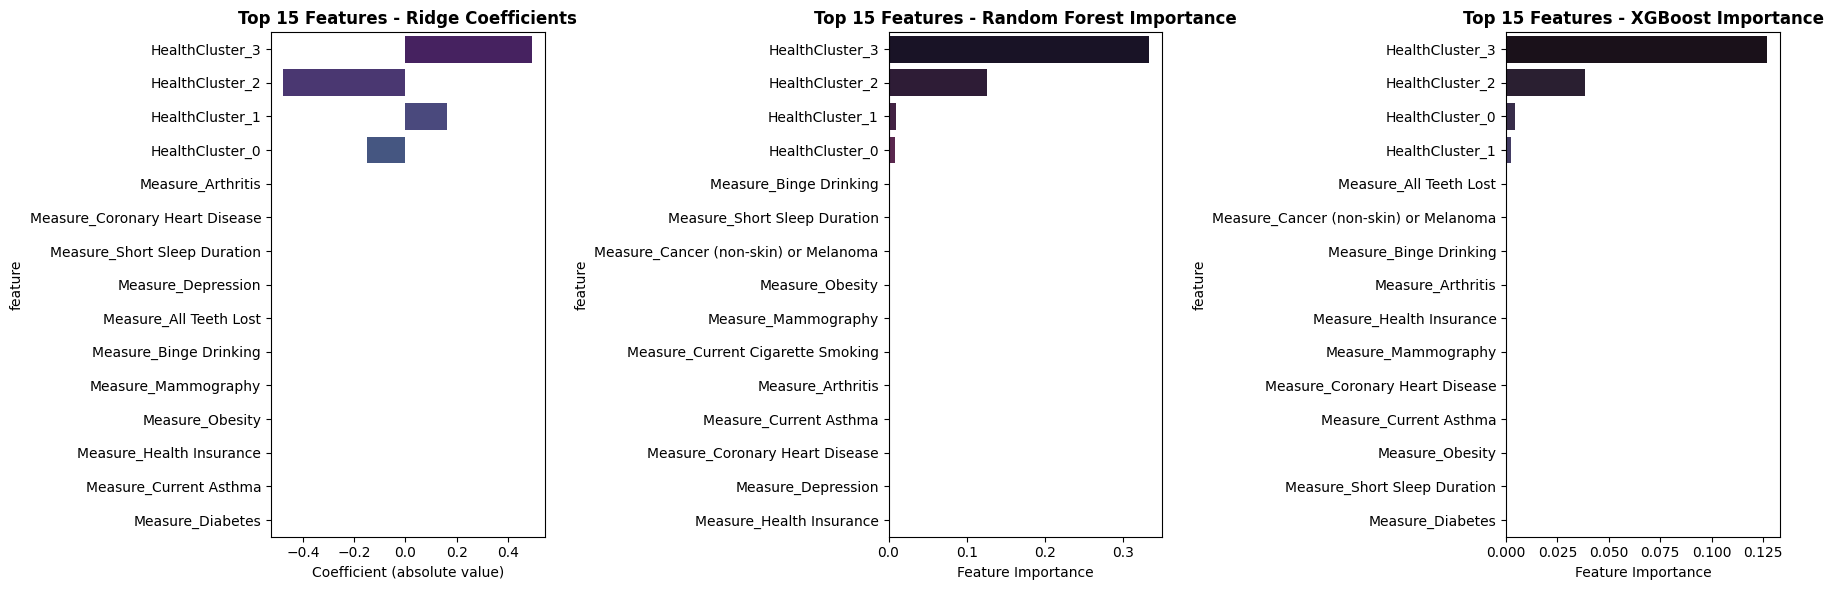

MODEL PERFORMANCE COMPARISON - TEST SET
           Model       R²      MSE      MAE
Ridge (Baseline) 0.424697 2.240000 1.075470
   Random Forest 0.410726 2.294398 1.088336
         XGBoost 0.423719 2.243811 1.065213


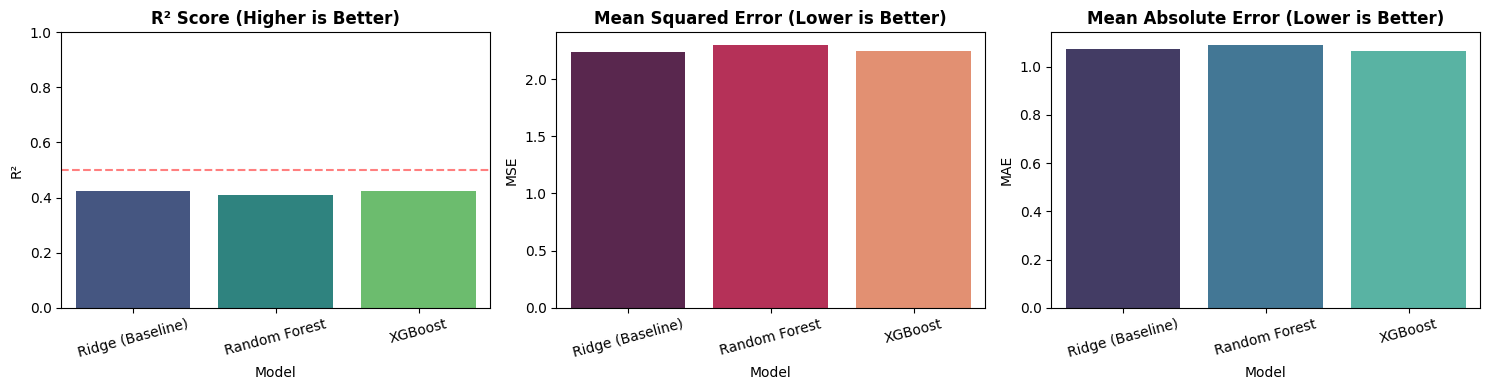

In [126]:
# Get feature names
feature_names = X.columns.tolist()


# Ridge coefficients
ridge_coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ridge.best_estimator_.coef_
}).sort_values('coefficient', key=abs, ascending=False)

# Random Forest importance
rf_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

# XGBoost importance
xgb_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

ridge_coef = ridge_coef[~ridge_coef['feature'].str.startswith('StateAbbr_')]
rf_imp = rf_imp[~rf_imp['feature'].str.startswith('StateAbbr_')]
xgb_imp = xgb_imp[~xgb_imp['feature'].str.startswith('StateAbbr_')]

# top 15 feature importances across all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=ridge_coef.head(15), y='feature', x='coefficient', ax=axes[0], palette='viridis', hue='feature', legend=False)
axes[0].set_title('Top 15 Features - Ridge Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient (absolute value)')

sns.barplot(data=rf_imp.head(15), y='feature', x='importance', ax=axes[1], palette='rocket', hue='feature', legend=False)
axes[1].set_title('Top 15 Features - Random Forest Importance', fontweight='bold')
axes[1].set_xlabel('Feature Importance')

sns.barplot(data=xgb_imp.head(15), y='feature', x='importance', ax=axes[2], palette='mako', hue='feature', legend=False)
axes[2].set_title('Top 15 Features - XGBoost Importance', fontweight='bold')
axes[2].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

# performance comparison visualizations
results = pd.DataFrame({
    'Model': ['Ridge (Baseline)', 'Random Forest', 'XGBoost'],
    'R²': [
        r2_score(y_test, ridge_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ],
    'MSE': [
        mean_squared_error(y_test, ridge_preds),
        mean_squared_error(y_test, rf_preds),
        mean_squared_error(y_test, xgb_preds)
    ],
    'MAE': [
        mean_absolute_error(y_test, ridge_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ]
})

print("MODEL PERFORMANCE COMPARISON - TEST SET")

print(results.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=results, x='Model', y='R²', ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')

sns.barplot(data=results, x='Model', y='MSE', ax=axes[1], palette='rocket', hue='Model', legend=False)
axes[1].set_title('Mean Squared Error (Lower is Better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=results, x='Model', y='MAE', ax=axes[2], palette='mako', hue='Model', legend=False)
axes[2].set_title('Mean Absolute Error (Lower is Better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#Results

###Feature Importance Analysis
Across all three models, the K-Means health clusters are consistently the strongest predictors of walkability. In Ridge, Random Forest, and XGBoost, `HealthCluster_3` (the healthiest cluster) and `HealthCluster_2` rank at the very top of the importance rankings, with `HealthCluster_0` and `HealthCluster_1` also appearing within the top group. This shows that overall health profiles, rather than any single condition, are most strongly associated with how walkable a county is.

###Model Performance Comparison

The three models we tested, Ridge Regression, Random Forest, and XGBoost, we observe moderate but consistent predictive performance, with clear differences in how each model learns patterns in the data.

Ridge Regression, our baseline linear model, achieves an R² of about 0.42, with an MSE of about 2.24 and an MAE of about 1.07. This indicates that Ridge captures a meaningful portion of walkability variation but still leaves substantial unexplained variance. The Ridge feature-importance plot highlights HealthCluster_3, HealthCluster_2, and related cluster indicators as the strongest predictors, reflecting broad county-level health differences.

Random Forest performs similarly, with an R² of about 0.41, and slightly worse error metrics (MSE of about 2.29, MAE of about 1.09). While the performance gap is small, the Random Forest feature-importance plot shows a narrower distribution of importance across predictors, with most importance concentrated in the top health clusters. This suggests that the model relies heavily on a small subset of features and captures fewer nuanced relationships than the linear or boosting models.

XGBoost achieves the strongest overall performance, with an R² of about 0.43, an MSE of of about 2.21, and the lowest MAE (of about 1.06). Although its R² is only slightly higher than Ridge, the error reductions are consistent. XGBoost’s feature-importance distribution is also more balanced, spreading importance across several health clusters and individual health indicators. This reflects XGBoost’s ability to learn modest nonlinear interactions without collapsing onto a single dominant feature.

Overall, Ridge provides a stable linear baseline, Random Forest is less reliable on this dataset, and XGBoost produces the most accurate and consistent predictions. The similarity in R² values across models also suggests that, once we exclude direct walkability components, county-level health variables explain only a moderate share of walkability differences. Models that can incorporate mild nonlinear signals (like XGBoost) do so slightly better, but all three models remain in the same overall performance band. This indicates that the variance in walkability cannot be further explained with more complex models and that 42% of variability is conclusively what our given health factors can predict in the walkability data.